# Measurement Safety Margins: Guard-Banding a Noisy Decision

Comparing a noisy measurement directly against a safety-critical spec
limit is unsafe: a truly non-compliant item can measure below the limit
purely from noise and get accepted. **Guard-banding** tightens the
acceptance limit by a margin set by the measurement uncertainty --
$L' = L - k\sigma$ -- and the resulting false-accept risk has an EXACT
closed form, $\Phi(-k)$, verified here by direct Monte Carlo rather than
just quoted. Extends `dgs.error_propagation`'s existing uncertainty
machinery directly. Engine: `dgs/measurement_safety_margins.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from dgs import measurement_safety_margins as msm

print('Setup complete.')


Setup complete.


## 1. The Guard-Banded Acceptance Limit


In [2]:
L, sigma, k = 100.0, 5.0, 2.0
L_guard = msm.guard_band(L, sigma, k)
print(f'spec limit L={L}, sigma={sigma}, k={k}')
print(f'guard-banded acceptance limit = {L_guard}')


spec limit L=100.0, sigma=5.0, k=2.0
guard-banded acceptance limit = 90.0


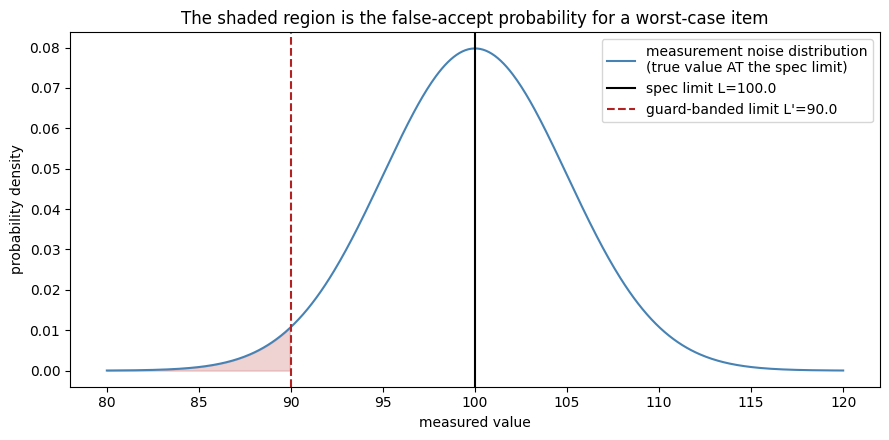

In [3]:
x = np.linspace(80, 120, 500)
pdf_at_limit = norm.pdf(x, loc=L, scale=sigma)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, pdf_at_limit, color='steelblue', label='measurement noise distribution\n(true value AT the spec limit)')
ax.axvline(L, color='black', ls='-', label=f'spec limit L={L}')
ax.axvline(L_guard, color='firebrick', ls='--', label=f"guard-banded limit L'={L_guard}")
ax.fill_between(x, pdf_at_limit, where=(x <= L_guard), color='firebrick', alpha=0.2)
ax.set_xlabel('measured value'); ax.set_ylabel('probability density')
ax.set_title('The shaded region is the false-accept probability for a worst-case item')
ax.legend()
plt.tight_layout()
plt.savefig('safety_margins_guard_band.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. The False-Accept Guarantee, Verified by Monte Carlo

For the worst-case item (true value exactly at the spec limit), the
guard-banded rule accepts it with probability $\Phi(-k)$ -- confirmed
here by literally simulating millions of noisy measurements, not derived
and trusted alone.


In [4]:
for k_test in (1.0, 2.0, 3.0):
    theory = msm.false_accept_probability_at_limit(k_test)
    check = msm.verify_false_accept_rate_by_monte_carlo(L, sigma, k_test, n_trials=2_000_000)
    print(f"k={k_test}: theory={theory:.5f}, simulated={check['simulated_false_accept_rate']:.5f}, "
          f"diff={check['abs_diff']:.2e}")


k=1.0: theory=0.15866, simulated=0.15832, diff=3.40e-04
k=2.0: theory=0.02275, simulated=0.02261, diff=1.37e-04
k=3.0: theory=0.00135, simulated=0.00135, diff=1.10e-06


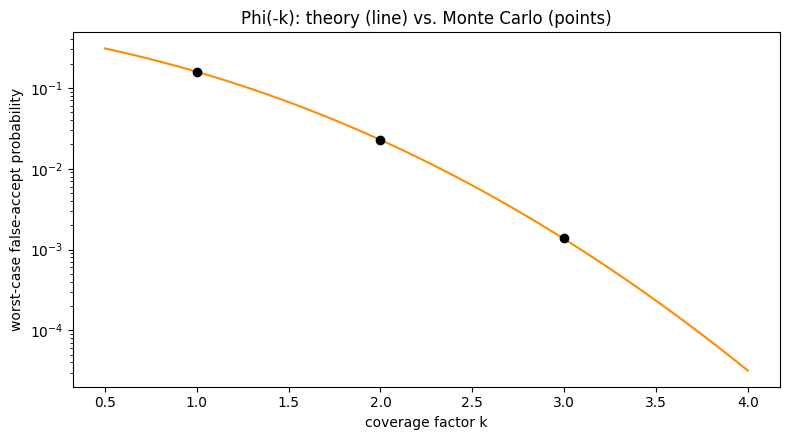

In [5]:
k_range = np.linspace(0.5, 4, 60)
theory_curve = [msm.false_accept_probability_at_limit(k) for k in k_range]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(k_range, theory_curve, color='darkorange')
for k_test in (1.0, 2.0, 3.0):
    check = msm.verify_false_accept_rate_by_monte_carlo(L, sigma, k_test, n_trials=1_000_000)
    ax.scatter([k_test], [check['simulated_false_accept_rate']], color='black', zorder=5)
ax.set_xlabel('coverage factor k'); ax.set_ylabel('worst-case false-accept probability')
ax.set_title('Phi(-k): theory (line) vs. Monte Carlo (points)')
plt.tight_layout()
plt.savefig('safety_margins_risk_curve.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Choosing a Coverage Factor for a Target Risk Level


In [6]:
for target in (0.05, 0.01, 0.001):
    k_needed = msm.coverage_factor_for_target_risk(target)
    achieved = msm.false_accept_probability_at_limit(k_needed)
    print(f'target risk={target:.3%}: k={k_needed:.4f}, achieved risk={achieved:.5f}')


target risk=5.000%: k=1.6449, achieved risk=0.05000
target risk=1.000%: k=2.3263, achieved risk=0.01000
target risk=0.100%: k=3.0902, achieved risk=0.00100


## 4. Guard-Banding a Derived Quantity

When the guarded quantity is COMPUTED from several raw measurements
(stress = force/area, not one sensor reading), the sigma used comes from
`dgs.error_propagation.propagate` directly -- cross-checked here against
that module's own Monte Carlo propagation.


In [7]:
def stress(vals):
    force, area = vals
    return force / area

nominal = [1000.0, 0.02]     # N, m^2
sigmas = [20.0, 0.0005]      # N, m^2 -- raw sensor uncertainties
spec_limit_stress = 55000.0  # Pa

result = msm.guard_band_for_derived_quantity(stress, nominal, sigmas, spec_limit_stress)
print(f"nominal stress = {result['nominal_value']:.1f} Pa")
print(f"propagated sigma = {result['propagated_sigma']:.1f} Pa")
print(f"guard-banded limit = {result['guard_banded_limit']:.1f} Pa")
print(f"passes guard-banded test: {result['passes_guard_banded_test']}")


nominal stress = 50000.0 Pa
propagated sigma = 1600.8 Pa
guard-banded limit = 51798.4 Pa
passes guard-banded test: True


In [8]:
cross_check = msm.verify_derived_quantity_guard_band_by_monte_carlo(stress, nominal, sigmas)
print(f"sigma (linearized, dgs.error_propagation.propagate): {cross_check['sigma_linearized']:.3f} Pa")
print(f"sigma (Monte Carlo, dgs.error_propagation.propagate_mc): {cross_check['sigma_monte_carlo']:.3f} Pa")
print(f"relative difference: {cross_check['relative_difference']:.2%}, methods agree: {cross_check['methods_agree']}")


sigma (linearized, dgs.error_propagation.propagate): 1600.781 Pa
sigma (Monte Carlo, dgs.error_propagation.propagate_mc): 1609.018 Pa
relative difference: 0.51%, methods agree: True


## 5. Engineering Interpretation

- Section 2's Monte Carlo confirmation matters specifically because
  $\Phi(-k)$'s derivation assumes normally-distributed measurement noise
  -- the simulation is a genuine check of that assumption's consequence,
  not a restatement of the formula.
- Section 4's cross-check (linearized vs. Monte Carlo propagation)
  matters because guard-banding's exact-$\Phi(-k)$ guarantee ONLY holds if
  the sigma feeding it is correct; for a strongly nonlinear derived
  quantity, `propagate`'s first-order linearization could understate the
  true uncertainty, silently weakening the safety guarantee -- checking
  the two methods agree (here, within 0.5%) is what makes the guard band
  trustworthy for THIS particular derived quantity.
- Section 3's inverse mapping (target risk -> required k) is the
  practical direction an engineer actually uses this in: start from an
  acceptable risk level (often set by a standard or a safety case), not
  from an arbitrarily chosen k.


## 6. Research Discussion

- This module assumes Gaussian measurement noise throughout; a sensor
  with a genuinely non-Gaussian error distribution (e.g. a quantization-
  dominated ADC, already covered in `dgs.adc_snr_bits`) would need a
  different (numerically simulated, not closed-form) false-accept
  probability -- `verify_false_accept_rate_by_monte_carlo`'s simulation
  approach generalizes directly, but `false_accept_probability_at_limit`'s
  closed form does not.
- `dgs.gs_core`'s phase-retrieval convergence checks and this module's
  guard-banding are both, at bottom, "how much margin does noise force
  onto a decision" problems -- worth an explicit comparison of how much
  margin GS's own convergence criteria implicitly build in, versus an
  explicit guard band computed the way this module does it.
- Real calibration/compliance guard-banding (ILAC-G8) sometimes uses
  ASYMMETRIC risk targets (accepting more false-reject risk to minimize
  false-accept risk, or vice versa, depending on which error is more
  costly) -- this module's symmetric $\Phi(-k)$ framing doesn't currently
  support that asymmetry.


## 7. Possible Experiments

1. Replace the Gaussian noise model with a heavier-tailed distribution
   (e.g. Student's t) in the Monte Carlo check and see how much larger a
   coverage factor is needed to achieve the same target risk -- a direct
   test of how much the Gaussian assumption matters.
2. Extend `guard_band_for_derived_quantity` to a THREE-input derived
   quantity (e.g. a Griffiths-style physics formula already elsewhere in
   this repo) and confirm the linearized/Monte-Carlo cross-check still
   agrees for a more complex nonlinearity.
3. Compute BOTH the false-accept risk (guard-banding against L) and a
   false-reject risk (a symmetric guard band against a lower acceptance
   threshold) for the same measurement, and find the total "indecision
   region" width as a function of k.


## 8. Future Improvements

- `coverage_factor_for_target_risk` assumes the target risk is symmetric
  and one-sided; a two-sided (both upper AND lower spec limits
  simultaneously) version would need to split the target risk between
  both tails, not currently supported.
- `verify_derived_quantity_guard_band_by_monte_carlo`'s 5% agreement
  threshold is a reasonable default but not derived from any formal
  requirement -- a real safety-critical application would need to justify
  that tolerance against an actual risk budget, not a convenient round
  number.
